EU LOBBYING TRANSPARENCY -- PHASE II DS ANAALYSIS 
TEAM RAMM | Data Sources: LobbyFacts.eu + World Bank API 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


In [15]:
## loads and looks at data 
 # Load LobbyFacts data
df = pd.read_csv('lobbyfacts_result__1_.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
df.head()

Shape: (16862, 11)

Columns: ['Identification code', 'Name', 'Members FTE', 'Lobbying cost', 'Interest represented', 'Head office', 'EU office', 'EP passes on 2026-05-25', 'all EP passes', 'Meetings', 'Lobbyfacts URL']

First 5 rows:


,Identification code,Name,Members FTE,Lobbying cost,Interest represented,Head office,EU office,EP passes on 2026-05-25,all EP passes,Meetings,Lobbyfacts URL
0,56047191389-84,Fleishman-Hillard,45.00,12730000,Advances interests of their clients,BELGIUM,BELGIUM,62.0,827.0,82.0,https://www.lobbyfacts.eu/datacard/fleishman-h...
1,28666427835-74,Meta Platforms Ireland Limited and its various...,16.95,10000000,Promotes their own interests or the collective...,IRELAND,BELGIUM,8.0,81.0,283.0,https://www.lobbyfacts.eu/datacard/meta-platfo...
2,455076325447-19,TUMO Center for Creative Technologies,15.35,10000000,Promotes their own interests or the collective...,ARMENIA,ARMENIA,NaN,NaN,2.0,https://www.lobbyfacts.eu/datacard/tumo-center...
3,621015197613-26,GOPA-Tech GmbH,0.30,10000000,Promotes their own interests or the collective...,GERMANY,GERMANY,NaN,NaN,3.0,https://www.lobbyfacts.eu/datacard/gopa-tech-g...
4,64879142323-90,CEFIC - European Chemical Industry Council,46.70,10000000,Promotes their own interests or the collective...,BELGIUM,BELGIUM,17.0,348.0,295.0,https://www.lobbyfacts.eu/datacard/cefic---eur...


In [16]:
## Will check for missing values 
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}))

print('\n=== Basic Stats ===')
print(df['Lobbying cost'].describe())

=== Missing Values ===
                         missing_count  missing_%
Identification code                  0        0.0
Name                                 0        0.0
Members FTE                          0        0.0
Lobbying cost                        0        0.0
Interest represented                 0        0.0
Head office                          0        0.0
EU office                            0        0.0
EP passes on 2026-05-25          13746       81.5
all EP passes                    12278       72.8
Meetings                          9686       57.4
Lobbyfacts URL                       0        0.0

=== Basic Stats ===
count    1.686200e+04
mean     1.076373e+05
std      4.069298e+05
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+04
75%      5.000000e+04
max      1.273000e+07
Name: Lobbying cost, dtype: float64


In [17]:
# Data Cleaning
df_clean = df.copy()

# Standardize country names from ALL CAPS to Title Case
df_clean['Head office'] = df_clean['Head office'].str.title().str.strip()
df_clean['EU office']   = df_clean['EU office'].str.title().str.strip()

# Fill missing numeric columns with 0, missing data will have zero instead 
df_clean['Meetings']                = df_clean['Meetings'].fillna(0)
df_clean['all EP passes']           = df_clean['all EP passes'].fillna(0)
df_clean['EP passes on 2026-05-25'] = df_clean['EP passes on 2026-05-25'].fillna(0)
df_clean['Members FTE']             = df_clean['Members FTE'].fillna(0)

df_clean = df_clean.drop(columns=['Identification code', 'Lobbyfacts URL'])

# Remove orgs with zero lobbying cost (no useful financial data)
# df_clean = df_clean[df_clean['Lobbying cost'] > 0]

print(f'Rows before cleaning: {len(df)}')
print(f'Rows after cleaning:  {len(df_clean)}')
print(f'\nSample countries after fix:')
print(df_clean['Head office'].value_counts().head(5))

Rows before cleaning: 16862
Rows after cleaning:  16862

Sample countries after fix:
Head office
Belgium    2656
Germany    2110
France     1564
Italy      1072
Spain      1047
Name: count, dtype: int64


In [18]:
# Save cleaned data
df_clean.to_csv('lobbyfacts_cleaned.csv', index=False)
print('Saved! Open lobbyfacts_cleaned.csv in your Explorer to see it.')

Saved! Open lobbyfacts_cleaned.csv in your Explorer to see it.


In [19]:
df_clean.head(20)

,Name,Members FTE,Lobbying cost,Interest represented,Head office,EU office,EP passes on 2026-05-25,all EP passes,Meetings
0,Fleishman-Hillard,45.00,12730000,Advances interests of their clients,Belgium,Belgium,62.0,827.0,82.0
1,Meta Platforms Ireland Limited and its various...,16.95,10000000,Promotes their own interests or the collective...,Ireland,Belgium,8.0,81.0,283.0
2,TUMO Center for Creative Technologies,15.35,10000000,Promotes their own interests or the collective...,Armenia,Armenia,0.0,0.0,2.0
3,GOPA-Tech GmbH,0.30,10000000,Promotes their own interests or the collective...,Germany,Germany,0.0,0.0,3.0
4,CEFIC - European Chemical Industry Council,46.70,10000000,Promotes their own interests or the collective...,Belgium,Belgium,17.0,348.0,295.0
5,INFINITE ORBITS,0.10,10000000,Promotes their own interests or the collective...,France,France,0.0,0.0,0.0
6,Amazon Europe Core SARL,8.90,9000000,Promotes their own interests or the collective...,Luxembourg,Luxembourg,11.0,79.0,213.0
7,Grindr LLC,0.30,9000000,Promotes their own interests or the collective...,United States,United States,0.0,0.0,3.0
8,FTI Consulting Belgium,54.50,8495000,Advances interests of their clients,United States,Belgium,52.0,575.0,104.0
9,Apple Inc.,8.40,8000000,Promotes their own interests or the collective...,United States,Belgium,9.0,82.0,175.0


In [20]:
# World Bank API - fetch country economic data
def fetch_world_bank(indicator, year=2022):
    url = f'https://api.worldbank.org/v2/country/all/indicator/{indicator}'
    params = {'date': year, 'format': 'json', 'per_page': 300}
    response = requests.get(url, params=params)
    data = response.json()
    
    if not isinstance(data, list) or len(data) < 2 or data[1] is None:
        print(f'  Warning: no data for {indicator}')
        return pd.DataFrame(columns=['country', 'iso2', indicator])
    
    records = []
    for entry in data[1]:
        if entry['value'] is not None:
            records.append({
                'country':  entry['country']['value'],
                'iso2':     entry['countryiso3code'],
                indicator:  entry['value']
            })
    
    df_wb = pd.DataFrame(records)
    print(f'  Fetched {len(df_wb)} countries for {indicator}')
    return df_wb

print('Fetching World Bank data...')
df_gdp       = fetch_world_bank('NY.GDP.MKTP.CD')
df_pop       = fetch_world_bank('SP.POP.TOTL')
df_inflation = fetch_world_bank('FP.CPI.TOTL.ZG')

# Merge all three
df_wb = df_gdp.merge(df_pop, on=['country', 'iso2'], how='outer')
df_wb = df_wb.merge(df_inflation, on=['country', 'iso2'], how='outer')

df_wb.rename(columns={
    'NY.GDP.MKTP.CD': 'gdp_usd',
    'SP.POP.TOTL':    'population',
    'FP.CPI.TOTL.ZG': 'inflation_rate'
}, inplace=True)

df_wb['gdp_per_capita'] = df_wb['gdp_usd'] / df_wb['population']

print(f'\nWorld Bank shape: {df_wb.shape}')
df_wb.head()

Fetching World Bank data...
  Fetched 257 countries for NY.GDP.MKTP.CD
  Fetched 265 countries for SP.POP.TOTL
  Fetched 180 countries for FP.CPI.TOTL.ZG

World Bank shape: (265, 6)


,country,iso2,gdp_usd,population,inflation_rate,gdp_per_capita
0,Afghanistan,AFG,1.449724e+10,40578842,13.712102,357.261153
1,Africa Eastern and Southern,AFE,1.228968e+12,731821393,10.883478,1679.327622
2,Africa Western and Central,AFW,1.063649e+12,497387180,7.949251,2138.473153
3,Albania,ALB,1.901725e+10,2451636,6.725203,7756.961887
4,Algeria,DZA,2.255816e+11,45477389,9.265516,4960.303343


In [21]:
# Merge LobbyFacts + World Bank
country_fixes = {
    'Czech Republic': 'Czechia',
    'South Korea': 'Korea, Rep.',
    'Russia': 'Russian Federation',
}

df_clean['country_merge'] = df_clean['Head office'].replace(country_fixes)

df_merged = df_clean.merge(df_wb, left_on='country_merge', right_on='country', how='left')

# Add lobbying to GDP ratio
df_merged['lobbying_gdp_ratio'] = df_merged['Lobbying cost'] / df_merged['gdp_usd'] * 1e9

matched = df_merged['gdp_usd'].notna().sum()
print(f'Total orgs: {len(df_merged)}')
print(f'Matched: {matched} ({matched/len(df_merged)*100:.1f}%)')

df_merged = df_merged.drop(columns=['Head office', 'EU office', 'country_merge', 'iso2'])
df_merged.head(5)

Total orgs: 16862
Matched: 16515 (97.9%)


,Name,Members FTE,Lobbying cost,Interest represented,EP passes on 2026-05-25,all EP passes,Meetings,country,gdp_usd,population,inflation_rate,gdp_per_capita,lobbying_gdp_ratio
0,Fleishman-Hillard,45.00,12730000,Advances interests of their clients,62.0,827.0,82.0,Belgium,5.910858e+11,11680210.0,9.597512,50605.749668,21536.637082
1,Meta Platforms Ireland Limited and its various...,16.95,10000000,Promotes their own interests or the collective...,8.0,81.0,283.0,Ireland,5.483418e+11,5212836.0,7.829457,105190.685953,18236.800657
2,TUMO Center for Creative Technologies,15.35,10000000,Promotes their own interests or the collective...,0.0,0.0,2.0,Armenia,1.951351e+10,2969200.0,8.640911,6571.974455,512465.556756
3,GOPA-Tech GmbH,0.30,10000000,Promotes their own interests or the collective...,0.0,0.0,3.0,Germany,4.201022e+12,83177813.0,6.872574,50506.517964,2380.373323
4,CEFIC - European Chemical Industry Council,46.70,10000000,Promotes their own interests or the collective...,17.0,348.0,295.0,Belgium,5.910858e+11,11680210.0,9.597512,50605.749668,16918.018132


In [22]:
# Save merged dataset
df_merged.to_csv('lobbyfacts_merged.csv', index=False)
print('Saved!')
print(f'Shape: {df_merged.shape}')
print(f'Columns: {list(df_merged.columns)}')

Saved!
Shape: (16862, 13)
Columns: ['Name', 'Members FTE', 'Lobbying cost', 'Interest represented', 'EP passes on 2026-05-25', 'all EP passes', 'Meetings', 'country', 'gdp_usd', 'population', 'inflation_rate', 'gdp_per_capita', 'lobbying_gdp_ratio']


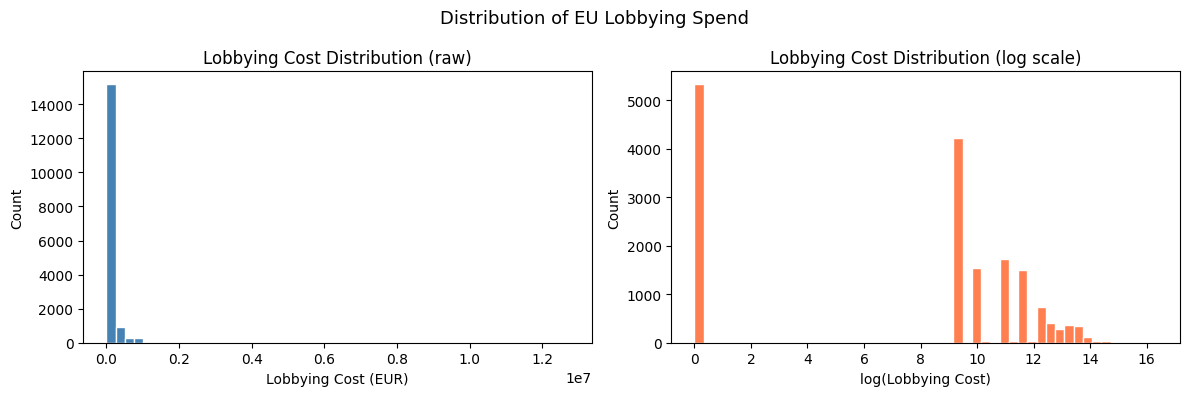

Plot 1 saved!


In [23]:
# EDA Plot 1 - Single variable: Distribution of lobbying cost
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].hist(df_merged['Lobbying cost'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Lobbying Cost Distribution (raw)')
axes[0].set_xlabel('Lobbying Cost (EUR)')
axes[0].set_ylabel('Count')

# Log transformed
axes[1].hist(np.log1p(df_merged['Lobbying cost']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Lobbying Cost Distribution (log scale)')
axes[1].set_xlabel('log(Lobbying Cost)')
axes[1].set_ylabel('Count')

plt.suptitle('Distribution of EU Lobbying Spend', fontsize=13)
plt.tight_layout()
plt.savefig('eda_plot1_lobbying_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 saved!')

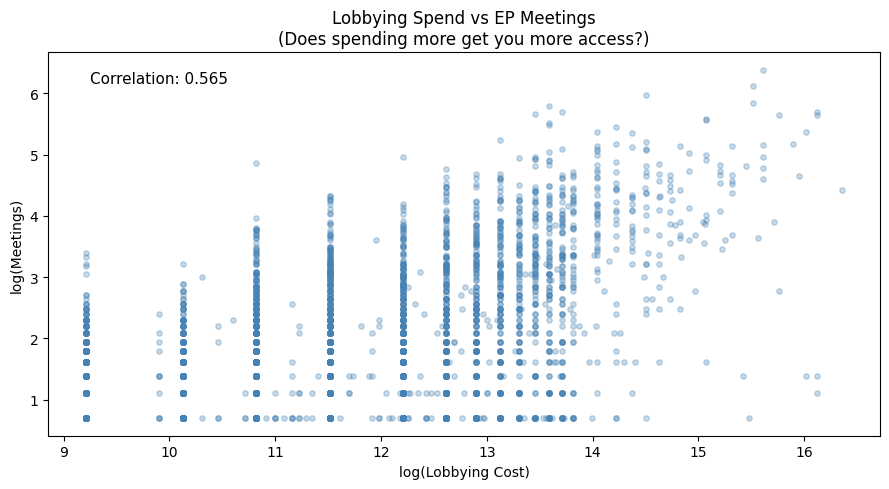

Correlation between spend and meetings: 0.565


In [24]:
# EDA Plot 2 - Two variable: Lobbying spend vs Meetings
df_plot = df_merged[(df_merged['Meetings'] > 0) & (df_merged['Lobbying cost'] > 0)].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    np.log1p(df_plot['Lobbying cost']),
    np.log1p(df_plot['Meetings']),
    alpha=0.3, color='steelblue', s=15
)
ax.set_xlabel('log(Lobbying Cost)')
ax.set_ylabel('log(Meetings)')
ax.set_title('Lobbying Spend vs EP Meetings\n(Does spending more get you more access?)')

correlation = df_plot['Lobbying cost'].corr(df_plot['Meetings'])
ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top')

plt.tight_layout()
plt.savefig('eda_plot2_spend_vs_meetings.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlation between spend and meetings: {correlation:.3f}')

In [26]:
# Prepare ML dataset - only orgs WITH meeting data
from sklearn.preprocessing import LabelEncoder

df_ml = df_merged[df_merged['Meetings'] > 0].copy()

# Encode categorical column
le = LabelEncoder()
df_ml['interest_encoded'] = le.fit_transform(df_ml['Interest represented'])

print(f'Orgs with meeting data: {len(df_ml)}')
print(f'Orgs without meeting data: {len(df_merged[df_merged["Meetings"] == 0])}')

Orgs with meeting data: 7176
Orgs without meeting data: 9686


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Log transform skewed features
df_ml['log_lobbying_cost'] = np.log1p(df_ml['Lobbying cost'])
df_ml['log_ep_passes'] = np.log1p(df_ml['all EP passes'])

feature_cols = [
    'log_lobbying_cost',
    'Members FTE',
    'log_ep_passes',
    'interest_encoded',
    'gdp_usd',
    'gdp_per_capita',
    'inflation_rate',
    'lobbying_gdp_ratio'
]

df_ml_clean = df_ml.dropna(subset=feature_cols + ['Meetings'])

X = df_ml_clean[feature_cols]
y = df_ml_clean['Meetings']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('=== Linear Regression Results ===')
print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.2f} meetings')
print(f'\nThe model explains {r2*100:.1f}% of variance in meeting counts')
print(f'Predictions are off by ~{rmse:.0f} meetings on average')

=== Linear Regression Results ===
R² Score: 0.0270
RMSE: 23.80 meetings

The model explains 2.7% of variance in meeting counts
Predictions are off by ~24 meetings on average
